In [5]:
from pathlib import Path
import os

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'deepfashion_mm'
DATA_DIR.mkdir(exist_ok=True)
print('Thư mục dữ liệu:', DATA_DIR)
print('Thư mục làm việc:', BASE_DIR)

Thư mục dữ liệu: c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm
Thư mục làm việc: c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36


# Chuẩn bị dữ liệu

In [6]:
import sys
import subprocess
from pathlib import Path

image_zip = BASE_DIR / 'images.zip'
if not image_zip.exists():
    image_zip = DATA_DIR / 'images.zip'

labels_zip = DATA_DIR / 'labels.zip'
LABELS_FILE_ID = '11WoM5ZFwWpVjrIvZajW0g8EmQCNKMAWH'

if image_zip.exists():
    print(f'Đã tìm thấy {image_zip.name}: {image_zip.stat().st_size / (1024**3):.2f} GB')
else:
    raise FileNotFoundError(
        'Không tìm thấy images.zip. Hãy đặt file cạnh notebook hoặc trong thư mục deepfashion_mm.'
    )

if not labels_zip.exists():
    print('Đang cài gdown để tải labels.zip...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
    import gdown
    print('Đang tải labels.zip...')
    downloaded = gdown.download(
        id=LABELS_FILE_ID,
        output=str(labels_zip),
        quiet=False,
    )
    if downloaded is None:
        raise RuntimeError('Không tải được labels.zip từ Google Drive.')
else:
    print('Đã tìm thấy labels.zip:', labels_zip)

print('Sẵn sàng giải nén dữ liệu.')

Đã tìm thấy images.zip: 6.35 GB
Đã tìm thấy labels.zip: c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels.zip
Sẵn sàng giải nén dữ liệu.


# Giải nén dữ liệu

Cell code có chức năng tạo hai thư mục `labels` và `images`, sau đó giải nén các file ZIP vào đúng vị trí. Cell có kiểm tra thư mục đích nên khi chạy lại sẽ bỏ qua phần đã giải nén, tránh mất thời gian xử lý lại ảnh.

In [17]:
import zipfile

LABELS_DIR = DATA_DIR / 'labels'
IMAGES_DIR = DATA_DIR / 'images'

if labels_zip.exists() and not LABELS_DIR.exists():
    LABELS_DIR.mkdir(parents=True)
    with zipfile.ZipFile(labels_zip, 'r') as archive:
        archive.extractall(LABELS_DIR)
    print('Đã giải nén labels.zip')

if image_zip.exists() and not IMAGES_DIR.exists():
    print('Đang giải nén images.zip')
    IMAGES_DIR.mkdir(parents=True)
    with zipfile.ZipFile(image_zip, 'r') as archive:
        archive.extractall(IMAGES_DIR)
    print('Đã giải nén images.zip')

# Một số bản ZIP có thêm thư mục images bên trong gói nén.
nested_images_dir = IMAGES_DIR / 'images'
if nested_images_dir.is_dir():
    IMAGES_DIR = nested_images_dir

print('Thư mục labels:', LABELS_DIR)
print('Thư mục ảnh thực tế:', IMAGES_DIR)
if IMAGES_DIR.exists():
    image_count = sum(1 for path in IMAGES_DIR.rglob('*') if path.is_file())
    print('Số file trong thư mục images:', image_count)
else:
    print('Chưa giải nén thư mục images.')

Thư mục labels: c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels
Thư mục ảnh thực tế: c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\images\images
Số file trong thư mục images: 44096


# Tìm các file annotation

Cell code ngay bên dưới quét đệ quy thư mục `labels` để tìm các file `.txt`. Danh sách này được dùng ở cell tiếp theo để xác định tự động file nhãn `shape`, `fabric` và `color`, thay vì ghi cứng đường dẫn.

In [10]:
import glob
import os

if os.path.exists(LABELS_DIR):
    label_files = glob.glob(os.path.join(LABELS_DIR, '**', '*.txt'), recursive=True)
    print('Các file annotation tìm thấy:')
    for f in label_files:
        print(' -', f)
else:
    label_files = []
    print('Lỗi thư mục labels không tồn tại, hãy chạy lại cell giải nén labels.zip trước')

Các file annotation tìm thấy:
 - c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels\labels\shape\shape_anno_all.txt
 - c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels\labels\texture\fabric_ann.txt
 - c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels\labels\texture\pattern_ann.txt


In [19]:
import pandas as pd

SHAPE_COLS = [
    'sleeve_length', 'lower_clothing_length', 'socks', 'hat', 'glasses',
    'neckwear', 'wrist_wearing', 'ring', 'waist_accessories', 'neckline',
    'outer_cardigan', 'upper_covering_navel'
]

SHAPE_MAPS = {
    'sleeve_length': {0: 'sleeveless', 1: 'short-sleeve', 2: 'medium-sleeve', 3: 'long-sleeve', 4: 'not long-sleeve', 5: 'NA'},
    'lower_clothing_length': {0: 'three-point', 1: 'medium short', 2: 'three-quarter', 3: 'long', 4: 'NA'},
    'socks': {0: 'no', 1: 'socks', 2: 'leggings', 3: 'NA'},
    'hat': {0: 'no', 1: 'yes', 2: 'NA'},
    'glasses': {0: 'no', 1: 'eyeglasses', 2: 'sunglasses', 3: 'has glasses in hand/clothes', 4: 'NA'},
    'neckwear': {0: 'no', 1: 'yes', 2: 'NA'},
    'wrist_wearing': {0: 'no', 1: 'yes', 2: 'NA'},
    'ring': {0: 'no', 1: 'yes', 2: 'NA'},
    'waist_accessories': {0: 'no', 1: 'belt', 2: 'has clothing', 3: 'hidden', 4: 'NA'},
    'neckline': {0: 'V-shape', 1: 'square', 2: 'round', 3: 'standing', 4: 'lapel', 5: 'suspenders', 6: 'NA'},
    'outer_cardigan': {0: 'yes', 1: 'no', 2: 'NA'},
    'upper_covering_navel': {0: 'no', 1: 'yes', 2: 'NA'},
}

FABRIC_COLS = ['upper_fabric', 'lower_fabric', 'outer_fabric']
FABRIC_MAP = {0: 'denim', 1: 'cotton', 2: 'leather', 3: 'furry', 4: 'knitted', 5: 'chiffon', 6: 'other', 7: 'NA'}

COLOR_COLS = ['upper_color', 'lower_color', 'outer_color']
COLOR_MAP = {0: 'floral', 1: 'graphic', 2: 'striped', 3: 'pure color', 4: 'lattice', 5: 'other', 6: 'color block', 7: 'NA'}


def load_anno(path, cols):
    """Đọc một file annotation bằng parser C của pandas."""
    return pd.read_csv(
        path,
        sep=r'\s+',
        header=None,
        names=['img_name'] + cols,
        dtype={'img_name': 'string'},
        engine='c',
    )


def find_annotation(keywords, description):
    """Tìm file annotation theo một hoặc nhiều từ khóa trong tên file."""
    matches = [
        path for path in label_files
        if any(keyword in path.lower() for keyword in keywords)
    ]
    if not matches:
        raise FileNotFoundError(
            f'Không tìm thấy file annotation cho {description}. '
            f'Các file hiện có: {label_files}'
        )
    return matches[0]


shape_path = find_annotation(['shape'], 'shape')
fabric_path = find_annotation(['fabric'], 'fabric')
# Bộ dữ liệu đặt tên nhãn màu/mẫu là pattern_ann.txt, không phải color_ann.txt.
color_path = find_annotation(['pattern', 'color'], 'color/pattern')

print('Shape annotation :', shape_path)
print('Fabric annotation:', fabric_path)
print('Color annotation :', color_path)

df_shape = load_anno(shape_path, SHAPE_COLS)
df_fabric = load_anno(fabric_path, FABRIC_COLS)
df_color = load_anno(color_path, COLOR_COLS)

for col in SHAPE_COLS:
    df_shape[col] = df_shape[col].map(SHAPE_MAPS[col])
for col in FABRIC_COLS:
    df_fabric[col] = df_fabric[col].map(FABRIC_MAP)
for col in COLOR_COLS:
    df_color[col] = df_color[col].map(COLOR_MAP)

print('Shape :', df_shape.shape)
print('Fabric:', df_fabric.shape)
print('Color :', df_color.shape)
df_shape.head()

Shape annotation : c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels\labels\shape\shape_anno_all.txt
Fabric annotation: c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels\labels\texture\fabric_ann.txt
Color annotation : c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm\labels\labels\texture\pattern_ann.txt
Shape : (42544, 13)
Fabric: (44096, 4)
Color : (44096, 4)


,img_name,sleeve_length,lower_clothing_length,socks,hat,glasses,neckwear,wrist_wearing,ring,waist_accessories,neckline,outer_cardigan,upper_covering_navel
0,MEN-Denim-id_00000080-01_7_additional.jpg,NA,long,no,no,no,no,no,no,hidden,round,no,yes
1,MEN-Denim-id_00000089-01_7_additional.jpg,sleeveless,long,no,no,no,no,no,no,hidden,round,no,yes
2,MEN-Denim-id_00000089-02_7_additional.jpg,long-sleeve,long,no,no,no,no,no,no,hidden,lapel,no,yes
3,MEN-Denim-id_00000089-03_7_additional.jpg,short-sleeve,long,no,no,no,no,no,no,hidden,round,no,yes
4,MEN-Denim-id_00000089-04_7_additional.jpg,long-sleeve,long,no,no,no,no,no,no,hidden,lapel,no,yes


# Đọc và giải mã annotation

Cell code ngay bên dưới đọc ba file nhãn bằng `pandas`, sau đó chuyển các mã số sang nhãn dễ hiểu bằng các bảng ánh xạ:

- `shape`: đặc điểm hình dáng và phụ kiện của trang phục.
- `fabric`: chất liệu của phần áo, quần và lớp ngoài.
- `color`: kiểu/mẫu màu của từng phần trang phục.

Kết quả là ba DataFrame: `df_shape`, `df_fabric` và `df_color`. Dùng parser C của pandas giúp đọc nhanh hơn vòng lặp Python thủ công.

In [20]:
# Gộp shape + fabric + color theo img_name
df = df_shape.merge(df_fabric, on='img_name', how='outer').merge(df_color, on='img_name', how='outer')

# Đồng bộ ID ảnh
df['image_id'] = 'dfmm_' + df['img_name']
image_root = IMAGES_DIR.relative_to(BASE_DIR).as_posix()
df['image_path'] = image_root + '/' + df['img_name']

# Sắp xếp lại cột cho dễ đọc: id trước, rồi tới thuộc tính
ordered_cols = ['image_id', 'image_path', 'img_name'] + SHAPE_COLS + FABRIC_COLS + COLOR_COLS
df = df[ordered_cols]

print('Tổng số dòng sau khi gộp:', len(df))
df.head()

Tổng số dòng sau khi gộp: 44096


,image_id,image_path,img_name,sleeve_length,lower_clothing_length,socks,hat,glasses,neckwear,wrist_wearing,...,waist_accessories,neckline,outer_cardigan,upper_covering_navel,upper_fabric,lower_fabric,outer_fabric,upper_color,lower_color,outer_color
0,dfmm_MEN-Denim-id_00000080-01_7_additional.jpg,deepfashion_mm/images/images/MEN-Denim-id_0000...,MEN-Denim-id_00000080-01_7_additional.jpg,NA,long,no,no,no,no,no,...,hidden,round,no,yes,cotton,cotton,NA,pure color,lattice,NA
1,dfmm_MEN-Denim-id_00000089-01_7_additional.jpg,deepfashion_mm/images/images/MEN-Denim-id_0000...,MEN-Denim-id_00000089-01_7_additional.jpg,sleeveless,long,no,no,no,no,no,...,hidden,round,no,yes,cotton,cotton,NA,pure color,pure color,NA
2,dfmm_MEN-Denim-id_00000089-02_7_additional.jpg,deepfashion_mm/images/images/MEN-Denim-id_0000...,MEN-Denim-id_00000089-02_7_additional.jpg,long-sleeve,long,no,no,no,no,no,...,hidden,lapel,no,yes,cotton,cotton,NA,striped,pure color,NA
3,dfmm_MEN-Denim-id_00000089-03_7_additional.jpg,deepfashion_mm/images/images/MEN-Denim-id_0000...,MEN-Denim-id_00000089-03_7_additional.jpg,short-sleeve,long,no,no,no,no,no,...,hidden,round,no,yes,cotton,cotton,NA,pure color,pure color,NA
4,dfmm_MEN-Denim-id_00000089-04_7_additional.jpg,deepfashion_mm/images/images/MEN-Denim-id_0000...,MEN-Denim-id_00000089-04_7_additional.jpg,long-sleeve,long,no,no,no,no,no,...,hidden,lapel,no,yes,denim,cotton,NA,pure color,pure color,NA


# Hợp nhất và xuất dữ liệu

Cell code ngay bên dưới ghép ba DataFrame theo tên ảnh `img_name`, tạo ID duy nhất `image_id`, tạo đường dẫn tương đối `image_path` và sắp xếp lại thứ tự cột. Sau đó, bảng đã hoàn chỉnh được xuất thành `deepfashion_mm_attributes.csv` ngay trong thư mục notebook, thay vì lưu vào Google Drive.

In [21]:
OUTPUT_CSV = os.path.join(BASE_DIR, 'deepfashion_mm_attributes.csv')
df.to_csv(OUTPUT_CSV, index=False)
print('Đã lưu:', OUTPUT_CSV)

Đã lưu: c:\Users\Nguyen Ho Vinh  Hien\Downloads\Week36\deepfashion_mm_attributes.csv


# Kiểm tra dữ liệu và xem ảnh mẫu

Hai cell code bên dưới thực hiện kiểm tra sau khi tạo bảng:

1. Đếm số dòng trong DataFrame/CSV và số file ảnh `.jpg` đã giải nén để phát hiện dữ liệu thiếu.
2. Chọn ngẫu nhiên 5 dòng, mở ảnh tương ứng và hiển thị một vài thuộc tính như `sleeve_length` và `neckline` để đối chiếu trực quan.

Nên chạy các cell theo thứ tự từ trên xuống để các biến như `df`, `IMAGES_DIR` và `DATA_DIR` đã được khởi tạo.

In [22]:
import glob
import os

# Đếm dòng CSV
if 'df' in locals():
    print('Số dòng trong CSV:', len(df))
    print('Kỳ vọng: 44096')

# Đếm số file ảnh thực tế đã giải nén để đối chiếu
if os.path.exists(IMAGES_DIR):
    all_images = glob.glob(os.path.join(IMAGES_DIR, '**', '*.jpg'), recursive=True)
    print('Số file ảnh thực tế đã tìm thấy:', len(all_images))
    if len(all_images) == 0:
        print('THƯ MỤC IMAGE ĐANG TRỐNH')
else:
    print('Thư mục image không tồn tại, hãy chạy lại cell trước')

Số dòng trong CSV: 44096
Kỳ vọng: 44096
Số file ảnh thực tế đã tìm thấy: 44096


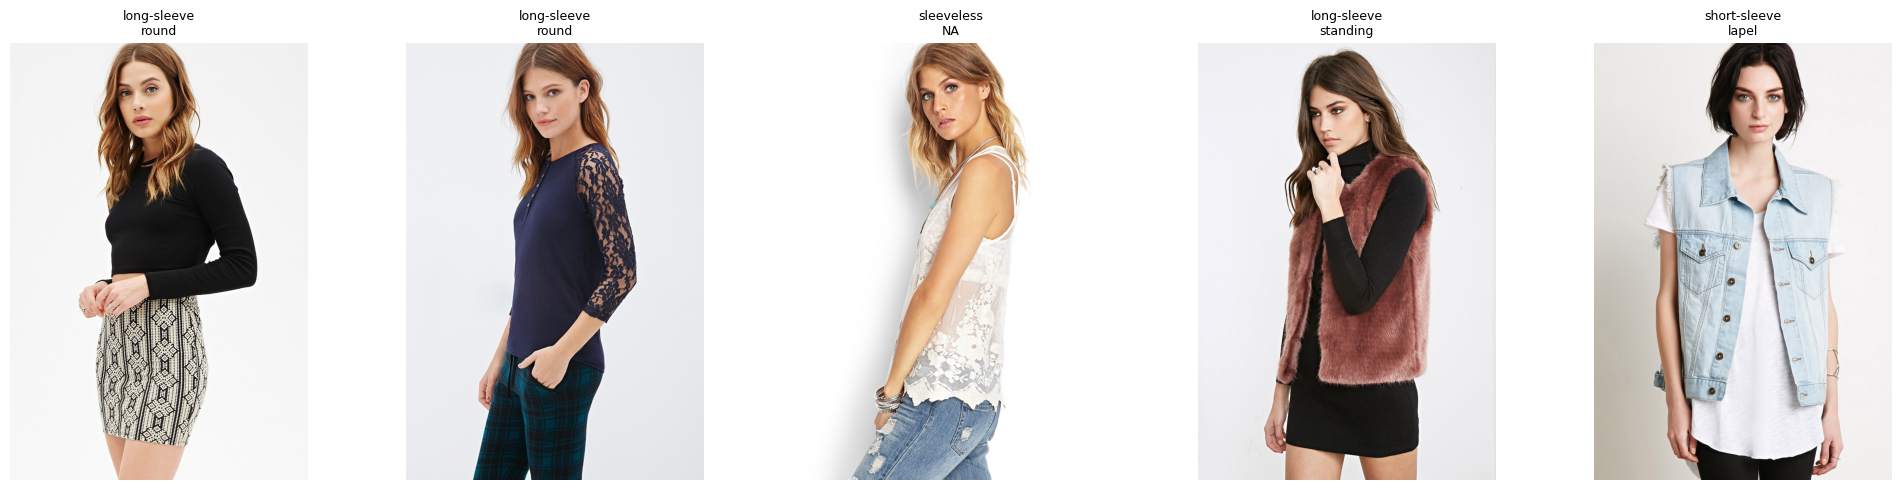

,image_id,image_path,img_name,sleeve_length,lower_clothing_length,socks,hat,glasses,neckwear,wrist_wearing,...,waist_accessories,neckline,outer_cardigan,upper_covering_navel,upper_fabric,lower_fabric,outer_fabric,upper_color,lower_color,outer_color
28626,dfmm_WOMEN-Skirts-id_00004947-01_1_front.jpg,deepfashion_mm/images/images/WOMEN-Skirts-id_0...,WOMEN-Skirts-id_00004947-01_1_front.jpg,long-sleeve,three-point,NA,no,no,no,no,...,hidden,round,no,no,cotton,cotton,NA,pure color,graphic,NA
38016,dfmm_WOMEN-Tees_Tanks-id_00003786-02_2_side.jpg,deepfashion_mm/images/images/WOMEN-Tees_Tanks-...,WOMEN-Tees_Tanks-id_00003786-02_2_side.jpg,long-sleeve,NA,NA,no,no,no,no,...,hidden,round,no,yes,cotton,cotton,NA,other,lattice,NA
7168,dfmm_WOMEN-Blouses_Shirts-id_00001846-01_2_sid...,deepfashion_mm/images/images/WOMEN-Blouses_Shi...,WOMEN-Blouses_Shirts-id_00001846-01_2_side.jpg,sleeveless,NA,NA,no,no,yes,yes,...,hidden,NA,no,yes,chiffon,denim,NA,graphic,pure color,NA
23208,dfmm_WOMEN-Jackets_Coats-id_00002228-01_2_side...,deepfashion_mm/images/images/WOMEN-Jackets_Coa...,WOMEN-Jackets_Coats-id_00002228-01_2_side.jpg,long-sleeve,three-point,NA,no,no,no,no,...,no,standing,yes,yes,knitted,knitted,furry,pure color,pure color,pure color
24431,dfmm_WOMEN-Jackets_Coats-id_00007450-02_4_full...,deepfashion_mm/images/images/WOMEN-Jackets_Coa...,WOMEN-Jackets_Coats-id_00007450-02_4_full.jpg,short-sleeve,NA,NA,no,no,no,yes,...,hidden,lapel,yes,yes,cotton,denim,denim,pure color,pure color,pure color


In [23]:
import random
from PIL import Image
import matplotlib.pyplot as plt

sample_rows = df.sample(5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = IMAGES_DIR / row['img_name']
    try:
        img = Image.open(img_path)
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'Không tìm thấy ảnh', ha='center')
    ax.set_title(f"{row['sleeve_length']}\n{row['neckline']}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

sample_rows